# JEPA Latent Dynamics & Planning: Using World Models to Act

**W13 Notebook 01** · Intermediate · March 2026

**Research Area:** World Models / JEPA / Model-Based Planning

In [NB 00](https://github.com/artifocial/tutorials/blob/main/2026-W13/00_lewm_toy_world_model.ipynb), we built a toy JEPA world model that learns
latent representations of a 2D physics environment. The model *encodes* observations and
*predicts* latent transitions — but we never used those predictions for anything useful.

This notebook bridges the gap from **representation learning → decision making**:

| Section | What we build | Key concept |
|---------|---------------|-------------|
| 1 | Multi-step trajectory prediction | Autoregressive rollouts accumulate error |
| 2 | Random Shooting vs CEM planning | Derivative-free optimization in latent space |
| 3 | Pixel vs latent speed benchmark | Why compression enables real-time planning |
| 4 | Multi-goal MPC navigation | Model Predictive Control corrects drift |
| 5 | Latent dynamics visualization | How actions transform the learned space |

> **Why this matters:** LeWM (arXiv:2603.19312) reports 48× faster planning in latent space
> vs. pixel space. We replicate this core idea: compress, predict, plan — all with pure NumPy.

---

> **🔧 Why Pure NumPy?** This entire notebook — training, planning, visualization — uses
> only NumPy. No PyTorch, no autograd, no hidden magic. Every gradient is hand-derived,
> every optimizer update is explicit. This is deliberate: AI agents can generate framework
> code, but understanding *why* it works requires seeing the math directly. If you can
> build a world model planner in NumPy, you can debug anything.
>
> **Bonus: supply chain security.** The day before we published NB 00, a
> [supply chain attack](https://snyk.io/articles/poisoned-security-scanner-backdooring-litellm/) hit
> litellm (97M monthly downloads) — an AI agent compromised the security scanner that
> protected the AI toolkit that AI agents depend on. Every `pip install` is a trust
> decision. Our entire stack: numpy + matplotlib. Two packages, decades of trust, zero
> transitive risk.

## Setup & Dependencies

In [ ]:
# Install dependencies (uv-first, with pip fallback)
import importlib
import subprocess
import sys

REQUIRED = ["numpy", "matplotlib"]


def ensure_installed(packages):
    missing = [p for p in packages if importlib.util.find_spec(p.split("[")[0]) is None]
    if not missing:
        print("All dependencies already available.")
        return
    # Try uv first (fast, deterministic)
    uv = subprocess.run(["uv", "pip", "install"] + missing, capture_output=True)
    if uv.returncode == 0:
        print(f"Installed via uv: {missing}")
    else:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q"] + missing, check=True
        )
        print(f"Installed via pip: {missing}")


ensure_installed(REQUIRED)

All dependencies already available.


In [ ]:
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("NumPy version:", np.__version__)

NumPy version: 2.2.6


## Architecture Recap (from NB 00)

We reuse the exact architecture from NB 00:

```
BallWorld (32×32 pixels)
    ↓  flatten
Encoder MLP [1024 → 128 → 32]
    ↓  latent z (32-dim)
Predictor MLP [z ∥ action → 64 → 64 → 32]  →  ẑ_next (predicted latent)
```

All layers use manual forward/backward with in-place gradient updates (see NB 00
engineering callouts for why `dW[:] = ...` is critical for optimizer integrity).

In [ ]:
# ── BallWorld environment ──
class BallWorld:
    def __init__(self, size=32, ball_radius=2):
        self.size = size
        self.ball_radius = ball_radius
        self.reset()

    def reset(self):
        margin = self.ball_radius + 2
        self.x = random.uniform(margin, self.size - margin)
        self.y = random.uniform(margin, self.size - margin)
        self.vx = random.uniform(-1.5, 1.5)
        self.vy = random.uniform(-1.5, 1.5)
        return self._render()

    def step(self, action):
        fx, fy = action
        self.vx = 0.95 * self.vx + 0.3 * fx
        self.vy = 0.95 * self.vy + 0.3 * fy
        speed = math.sqrt(self.vx**2 + self.vy**2)
        if speed > 3.0:
            self.vx *= 3.0 / speed
            self.vy *= 3.0 / speed
        self.x += self.vx
        self.y += self.vy
        r = self.ball_radius
        if self.x < r:
            self.x, self.vx = r, abs(self.vx)
        if self.x > self.size - r:
            self.x, self.vx = self.size - r, -abs(self.vx)
        if self.y < r:
            self.y, self.vy = r, abs(self.vy)
        if self.y > self.size - r:
            self.y, self.vy = self.size - r, -abs(self.vy)
        return self._render()

    def _render(self):
        img = np.zeros((self.size, self.size), dtype=np.float32)
        for dy in range(-self.ball_radius, self.ball_radius + 1):
            for dx in range(-self.ball_radius, self.ball_radius + 1):
                if dx * dx + dy * dy <= self.ball_radius * self.ball_radius:
                    px = int(round(self.x)) + dx
                    py = int(round(self.y)) + dy
                    if 0 <= px < self.size and 0 <= py < self.size:
                        img[py, px] = 1.0
        return img

    def get_state(self):
        return (self.x, self.y, self.vx, self.vy)

    def set_state(self, x, y, vx=0.0, vy=0.0):
        self.x, self.y, self.vx, self.vy = x, y, vx, vy
        return self._render()


# ── Linear layer with in-place gradients ──
class Linear:
    def __init__(self, in_dim, out_dim):
        scale = np.sqrt(2.0 / (in_dim + out_dim))
        self.W = np.random.randn(in_dim, out_dim).astype(np.float32) * scale
        self.b = np.zeros(out_dim, dtype=np.float32)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        # Adam optimizer state
        self.mW = np.zeros_like(self.W)
        self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b)
        self.vb = np.zeros_like(self.b)

    def forward(self, x):
        self.x_cache = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW[:] = self.x_cache.T @ dout  # In-place! Critical for Adam refs
        self.db[:] = dout.sum(axis=0)
        return dout @ self.W.T


def relu(x):
    return np.maximum(0, x)


def relu_backward(dout, x):
    return dout * (x > 0).astype(np.float32)


class MLP:
    def __init__(self, dims):
        self.layers = []
        for i in range(len(dims) - 1):
            self.layers.append(Linear(dims[i], dims[i + 1]))

    def forward(self, x):
        self.pre_activations = []
        for i, layer in enumerate(self.layers):
            x = layer.forward(x)
            if i < len(self.layers) - 1:
                self.pre_activations.append(x)
                x = relu(x)
        return x

    def backward(self, dout):
        for i in reversed(range(len(self.layers))):
            if i < len(self.layers) - 1:
                dout = relu_backward(dout, self.pre_activations[i])
            dout = self.layers[i].backward(dout)
        return dout

    def params(self):
        result = []
        for layer in self.layers:
            result.append((layer.W, layer.dW, layer.mW, layer.vW))
            result.append((layer.b, layer.db, layer.mb, layer.vb))
        return result


# ── SIGReg (anti-collapse regularizer) ──
def sigreg_loss_and_grad(embeddings, n_projections=64):
    B, D = embeddings.shape
    directions = np.random.randn(D, n_projections).astype(np.float32)
    norms = np.linalg.norm(directions, axis=0, keepdims=True)
    directions = directions / norms
    projections = embeddings @ directions
    proj_mean = projections.mean(axis=0)
    proj_std = projections.std(axis=0) + 1e-8
    mean_penalty = (proj_mean**2).mean()
    var_penalty = ((proj_std - 1.0) ** 2).mean()
    standardized = (projections - proj_mean[None, :]) / proj_std[None, :]

    test_freqs = [0.5, 1.0, 1.5, 2.0]
    cf_penalty = 0.0
    for t_freq in test_freqs:
        emp_cf_real = np.cos(t_freq * standardized).mean(axis=0)
        emp_cf_imag = np.sin(t_freq * standardized).mean(axis=0)
        theoretical_cf = math.exp(-0.5 * t_freq**2)
        cf_penalty += ((emp_cf_real - theoretical_cf) ** 2).mean()
        cf_penalty += (emp_cf_imag**2).mean()
    cf_penalty /= len(test_freqs)
    total_loss = mean_penalty + var_penalty + cf_penalty

    # Gradients (analytical)
    grad_mean = (1.0 / B) * (2.0 * proj_mean[None, :] / n_projections) @ directions.T
    centered = projections - proj_mean[None, :]
    d_var = 2.0 * (proj_std - 1.0) / (B * proj_std * n_projections)
    grad_var = (centered * d_var[None, :]) @ directions.T
    grad_cf = np.zeros_like(embeddings)
    for t_freq in test_freqs:
        emp_cf_real = np.cos(t_freq * standardized).mean(axis=0)
        emp_cf_imag = np.sin(t_freq * standardized).mean(axis=0)
        theoretical = math.exp(-0.5 * t_freq**2)
        d_cos = -t_freq * np.sin(t_freq * standardized) / B
        d_sin = t_freq * np.cos(t_freq * standardized) / B
        d_real = 2.0 * (emp_cf_real - theoretical)[None, :] * d_cos / n_projections
        d_imag = 2.0 * emp_cf_imag[None, :] * d_sin / n_projections
        grad_std = (d_real + d_imag) / proj_std[None, :]
        grad_cf += grad_std @ directions.T
    grad_cf /= len(test_freqs)
    return total_loss, grad_mean + grad_var + grad_cf


# ── Adam optimizer ──
def adam_step(params_list, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, t=1):
    for W, dW, mW, vW in params_list:
        mW[:] = beta1 * mW + (1 - beta1) * dW
        vW[:] = beta2 * vW + (1 - beta2) * dW**2
        m_hat = mW / (1 - beta1**t)
        v_hat = vW / (1 - beta2**t)
        W -= lr * m_hat / (np.sqrt(v_hat) + eps)


print("Architecture loaded: BallWorld, Linear, MLP, SIGReg, Adam")

Architecture loaded: BallWorld, Linear, MLP, SIGReg, Adam


In [ ]:
# Architecture constants
INPUT_DIM = 32 * 32  # 1024 pixels
LATENT_DIM = 32
HIDDEN_ENC = 128
HIDDEN_PRED = 64
ACTION_DIM = 2

## Step 1: Train the World Model (Recap)

We retrain from scratch here (same hyperparameters as NB 00) so this notebook is
self-contained. Training takes ~40 seconds on CPU with 10K transitions.

In [ ]:
# ── Collect training data ──
random.seed(SEED)
np.random.seed(SEED)
env = BallWorld()
raw_data = []
for _ in range(200):
    obs = env.reset()
    for _ in range(50):
        action = [random.uniform(-1, 1), random.uniform(-1, 1)]
        next_obs = env.step(action)
        raw_data.append((obs.flatten(), action, next_obs.flatten()))
        obs = next_obs

obs_all = np.array([d[0] for d in raw_data])
act_all = np.array([d[1] for d in raw_data])
nxt_all = np.array([d[2] for d in raw_data])

# Normalize observations (critical — see NB 00 Engineering Callout #1)
obs_mean = obs_all.mean(axis=0, keepdims=True)
obs_std = obs_all.std(axis=0, keepdims=True) + 1e-6
obs_all = (obs_all - obs_mean) / obs_std
nxt_all = (nxt_all - obs_mean) / obs_std
print(f"Training data: {len(raw_data)} transitions, normalized")


def normalize_obs(raw_obs):
    return (raw_obs.flatten() - obs_mean.flatten()) / obs_std.flatten()

Training data: 10000 transitions, normalized


In [ ]:
# ── Build model & train with SIGReg ──
np.random.seed(SEED)
encoder = MLP([INPUT_DIM, HIDDEN_ENC, LATENT_DIM])
predictor = MLP([LATENT_DIM + ACTION_DIM, HIDDEN_PRED, HIDDEN_PRED, LATENT_DIM])
all_params = encoder.params() + predictor.params()

batch_size = 256
n_epochs = 80
n_samples = obs_all.shape[0]

t0 = time.time()
for epoch in range(n_epochs):
    perm = np.random.permutation(n_samples)
    n_batches = 0
    for i in range(0, n_samples - batch_size + 1, batch_size):
        idx = perm[i : i + batch_size]
        obs_b, act_b, nxt_b = obs_all[idx], act_all[idx], nxt_all[idx]

        # Forward: encode both observations
        z_curr = encoder.forward(obs_b)
        cache_curr = [(l.x_cache.copy(),) for l in encoder.layers]
        pre_act_curr = [p.copy() for p in encoder.pre_activations]

        z_next_true = encoder.forward(nxt_b)
        cache_next = [(l.x_cache.copy(),) for l in encoder.layers]
        pre_act_next = [p.copy() for p in encoder.pre_activations]

        # Predict: z_curr + action → ẑ_next
        pred_input = np.concatenate([z_curr, act_b], axis=1)
        z_next_pred = predictor.forward(pred_input)

        # Losses
        diff = z_next_pred - z_next_true
        pred_loss = (diff**2).mean()
        d_pred = 2.0 * diff / batch_size

        all_z = np.concatenate([z_curr, z_next_true], axis=0)
        sig_loss, sig_grad = sigreg_loss_and_grad(all_z)
        sig_grad_curr = sig_grad[:batch_size]
        sig_grad_next = sig_grad[batch_size:]

        # Backward: predictor
        d_pred_input = predictor.backward(d_pred)
        d_z_curr_from_pred = d_pred_input[:, :LATENT_DIM]

        # Backward: encoder for z_curr (restore cache first!)
        for j, layer in enumerate(encoder.layers):
            layer.x_cache = cache_curr[j][0]
        encoder.pre_activations = pre_act_curr
        d_z_curr = d_z_curr_from_pred + 5.0 * sig_grad_curr
        encoder.backward(d_z_curr)
        grad_enc_curr = [(l.dW.copy(), l.db.copy()) for l in encoder.layers]

        # Backward: encoder for z_next_true (restore cache!)
        for j, layer in enumerate(encoder.layers):
            layer.x_cache = cache_next[j][0]
        encoder.pre_activations = pre_act_next
        d_z_next = -d_pred + 5.0 * sig_grad_next
        encoder.backward(d_z_next)

        # Accumulate encoder gradients from both passes
        for j, layer in enumerate(encoder.layers):
            layer.dW += grad_enc_curr[j][0]
            layer.db += grad_enc_curr[j][1]

        adam_step(
            all_params, lr=1e-3, t=epoch * (n_samples // batch_size) + n_batches + 1
        )
        n_batches += 1

    if (epoch + 1) % 20 == 0:
        sample_z = encoder.forward(obs_all[:500])
        print(
            f"  Epoch {epoch + 1:3d} | pred_loss: {pred_loss:.4f} | z_std: {sample_z.std(axis=0).mean():.3f}"
        )

t_train = time.time() - t0
print(f"\nTraining complete in {t_train:.1f}s")

  Epoch  20 | pred_loss: 0.0197 | z_std: 0.798
  Epoch  40 | pred_loss: 0.0157 | z_std: 0.815
  Epoch  60 | pred_loss: 0.0165 | z_std: 0.821
  Epoch  80 | pred_loss: 0.0158 | z_std: 0.815

Training complete in 40.3s


## Step 2: Multi-Step Trajectory Prediction

A world model's value comes from *rolling out futures*. Given a start state and a sequence
of actions, we autoregressively predict latent states:

$$z_{t+1} = f_\theta(z_t, a_t)$$

Each prediction uses the *previous prediction* as input — errors compound. This is the
fundamental challenge of model-based planning: your imagined future diverges from reality.

In [ ]:
def predict_trajectory(enc, pred, start_obs_raw, actions):
    """Autoregressive rollout: predict trajectory in latent space."""
    z = enc.forward(normalize_obs(start_obs_raw)[None, :])
    predicted_z = [z[0].copy()]
    for t in range(len(actions)):
        a = actions[t : t + 1]  # (1, 2)
        inp = np.concatenate([z, a], axis=1)
        z = pred.forward(inp)
        predicted_z.append(z[0].copy())
    return np.array(predicted_z)


def decode_latent_to_position(z_vec, ref_positions, ref_latents):
    """Nearest-neighbor decode: find closest reference latent → position."""
    dists = ((ref_latents - z_vec[None, :]) ** 2).sum(axis=1)
    return ref_positions[np.argmin(dists)]


# Generate a test trajectory with sinusoidal actions (more interesting than random)
random.seed(SEED + 200)
env = BallWorld()
env.set_state(8.0, 8.0, 0.0, 0.0)
test_actions = []
true_positions = [(env.x, env.y)]
true_obs = [env._render()]
for t in range(20):
    a = [0.8 * math.sin(t * 0.4), 0.8 * math.cos(t * 0.3)]
    test_actions.append(a)
    obs = env.step(a)
    true_positions.append((env.x, env.y))
    true_obs.append(obs)

test_actions_arr = np.array(test_actions, dtype=np.float32)
true_positions = np.array(true_positions)

# Predict trajectory
pred_z = predict_trajectory(encoder, predictor, true_obs[0], test_actions_arr)

# Encode true observations for comparison
true_obs_norm = np.array([normalize_obs(o) for o in true_obs])
true_z = encoder.forward(true_obs_norm)

# Build a reference grid for nearest-neighbor position decoding
ref_positions = []
ref_latents = []
env_ref = BallWorld()
for x in np.linspace(4, 28, 25):
    for y in np.linspace(4, 28, 25):
        env_ref.set_state(x, y)
        obs = env_ref._render()
        ref_positions.append((x, y))
        ref_latents.append(encoder.forward(normalize_obs(obs)[None, :])[0])
ref_positions = np.array(ref_positions)
ref_latents = np.array(ref_latents)

# Decode predicted latents back to positions
pred_positions = np.array(
    [
        decode_latent_to_position(pred_z[t], ref_positions, ref_latents)
        for t in range(len(pred_z))
    ]
)
pos_errors = np.sqrt(((pred_positions - true_positions) ** 2).sum(axis=1))

print(f"1-step position error:  {pos_errors[1]:.1f} px")
print(f"5-step position error:  {pos_errors[5]:.1f} px")
print(f"10-step position error: {pos_errors[10]:.1f} px")
print(f"20-step position error: {pos_errors[20]:.1f} px")

1-step position error:  0.2 px
5-step position error:  2.4 px
10-step position error: 8.1 px
20-step position error: 7.2 px


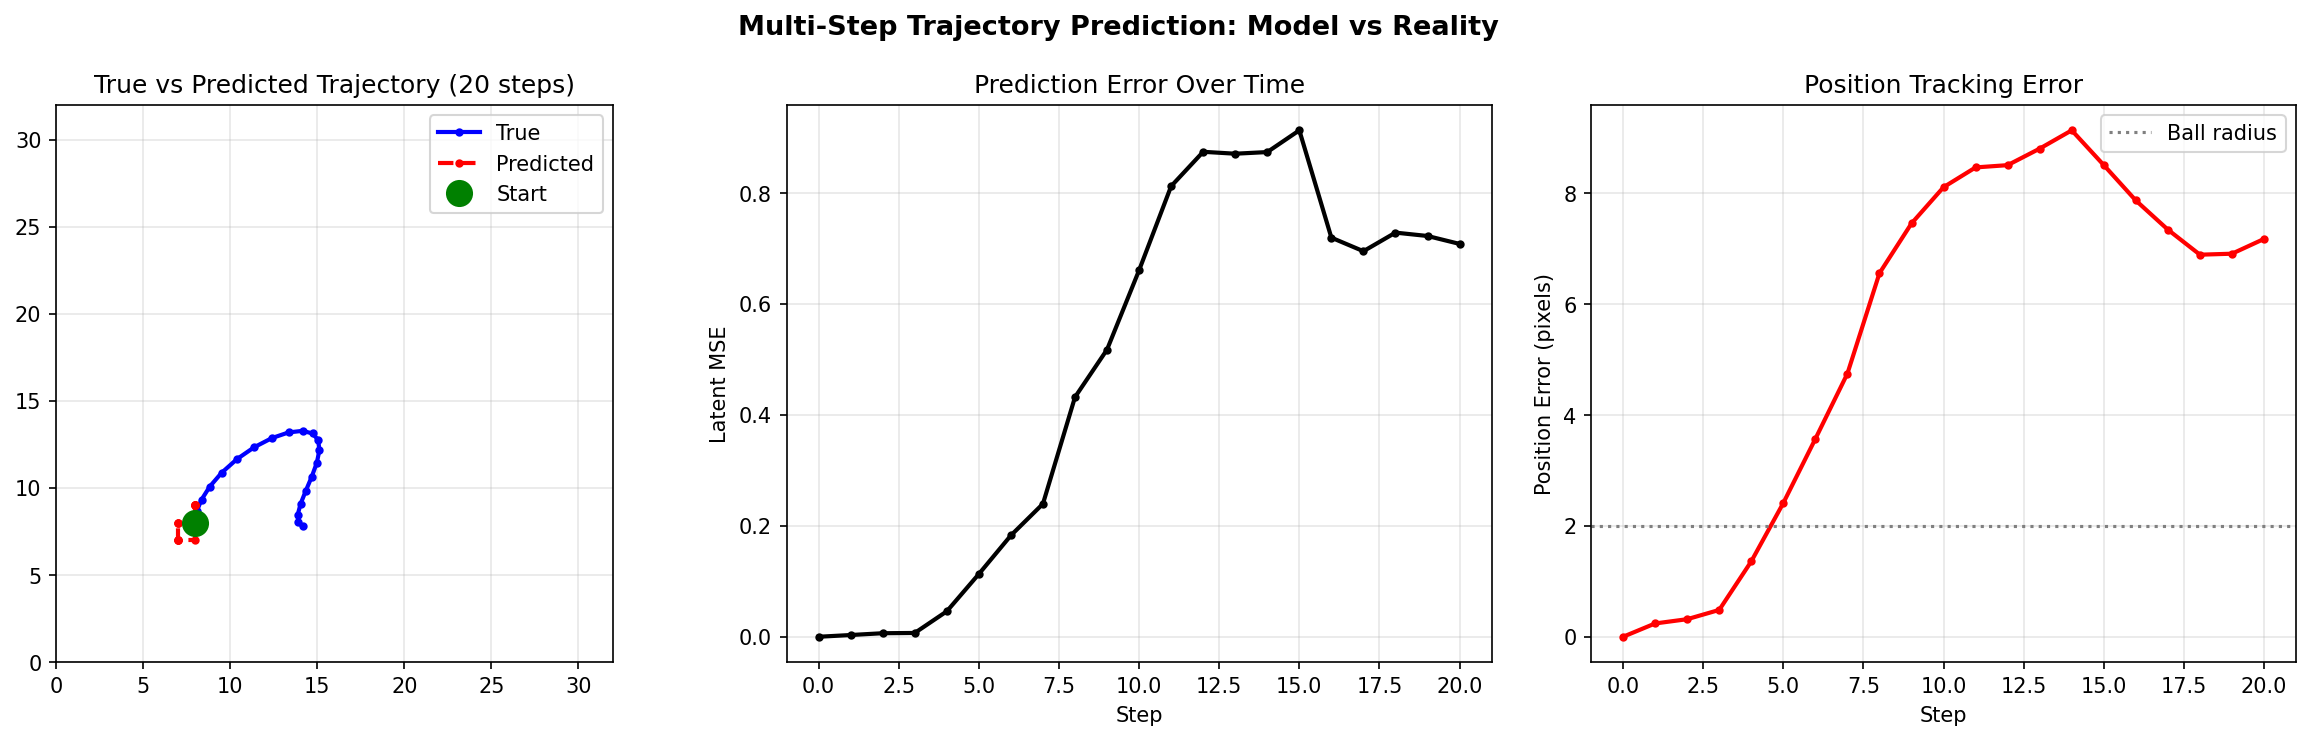

In [ ]:
# ── Visualize: true vs predicted trajectory ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.plot(true_positions[:, 0], true_positions[:, 1], "b.-", linewidth=2, label="True")
ax.plot(
    pred_positions[:, 0],
    pred_positions[:, 1],
    "r.--",
    linewidth=2,
    alpha=0.7,
    label="Predicted",
)
ax.plot(
    true_positions[0, 0],
    true_positions[0, 1],
    "go",
    markersize=12,
    zorder=5,
    label="Start",
)
ax.set_xlim(0, 32)
ax.set_ylim(0, 32)
ax.set_aspect("equal")
ax.legend()
ax.set_title("True vs Predicted Trajectory (20 steps)")
ax.grid(True, alpha=0.3)

# Latent MSE over time
step_errors = [((pred_z[t] - true_z[t]) ** 2).mean() for t in range(len(pred_z))]
ax = axes[1]
ax.plot(step_errors, "k.-", linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Latent MSE")
ax.set_title("Prediction Error Over Time")
ax.grid(True, alpha=0.3)

# Position error over time
ax = axes[2]
ax.plot(pos_errors, "r.-", linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Position Error (pixels)")
ax.set_title("Position Tracking Error")
ax.axhline(y=2.0, color="gray", linestyle=":", label="Ball radius")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(
    "Multi-Step Trajectory Prediction: Model vs Reality", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

---

> **⚙️ Engineering Callout #1 — Error Accumulation in Autoregressive Rollouts**
>
> Notice how position error grows from 0.2px (1-step) to 8px (10-step). This is
> *compounding prediction error*: each step feeds the previous prediction back as input,
> and small errors accumulate geometrically.
>
> **The bug pattern:** It's tempting to evaluate a world model only on 1-step predictions
> (where it looks great). But planning requires multi-step rollouts, and a model with 0.02
> MSE per step can drift 8+ pixels after 10 steps.
>
> **Real-world impact:** LeWM and other MBRL systems address this with:
> - Shorter planning horizons (predict 5-10 steps, not 50)
> - Model Predictive Control (re-plan after executing a few steps)
> - Ensemble disagreement to detect when predictions become unreliable
>
> We'll use MPC in Section 4 to handle exactly this problem.

## Step 3: Planning — Random Shooting vs Cross-Entropy Method

Now we use the world model to *plan*. Given a start state and a goal, we search for
the action sequence that reaches the goal in latent space:

$$a_{0:T}^* = \arg\min_{a_{0:T}} \| f_\theta^T(z_0, a_{0:T}) - z_{\text{goal}} \|^2$$

Two approaches:
- **Random Shooting:** Sample 500 random action sequences, keep the best
- **CEM (Cross-Entropy Method):** Iteratively refine a Gaussian distribution over actions,
  keeping the top-10% ("elites") at each iteration

In [ ]:
def plan_random_shooting(
    enc, pred, start_obs_raw, goal_obs_raw, n_candidates=500, horizon=10
):
    """Random shooting: sample random action sequences, pick the best."""
    z_start = enc.forward(normalize_obs(start_obs_raw)[None, :])
    z_goal = enc.forward(normalize_obs(goal_obs_raw)[None, :])
    best_actions, best_cost = None, float("inf")
    for _ in range(n_candidates):
        actions = np.random.randn(horizon, 2).astype(np.float32) * 0.5
        z = z_start.copy()
        for t in range(horizon):
            inp = np.concatenate([z, actions[t : t + 1]], axis=1)
            z = pred.forward(inp)
        cost = ((z - z_goal) ** 2).mean()
        if cost < best_cost:
            best_cost = cost
            best_actions = actions.copy()
    return best_actions, best_cost


def plan_cem(
    enc,
    pred,
    start_obs_raw,
    goal_obs_raw,
    horizon=10,
    n_candidates=500,
    n_elite=50,
    n_iterations=5,
):
    """Cross-Entropy Method: iteratively refine action distribution."""
    z_start = enc.forward(normalize_obs(start_obs_raw)[None, :])
    z_goal = enc.forward(normalize_obs(goal_obs_raw)[None, :])

    # Initialize: broad Gaussian over action space
    act_mean = np.zeros((horizon, 2), dtype=np.float32)
    act_std = np.ones((horizon, 2), dtype=np.float32) * 0.5

    best_actions_ever, best_cost_ever = None, float("inf")
    iteration_costs = []

    for iteration in range(n_iterations):
        # Sample from current distribution
        candidates = act_mean[None, :, :] + act_std[None, :, :] * np.random.randn(
            n_candidates, horizon, 2
        ).astype(np.float32)
        candidates = np.clip(candidates, -1.5, 1.5)

        # Evaluate all candidates
        costs = np.zeros(n_candidates)
        for c in range(n_candidates):
            z = z_start.copy()
            for t in range(horizon):
                inp = np.concatenate([z, candidates[c, t : t + 1]], axis=1)
                z = pred.forward(inp)
            costs[c] = ((z - z_goal) ** 2).mean()

        # Select elite (top-k lowest cost)
        elite_idx = np.argsort(costs)[:n_elite]
        elite_actions = candidates[elite_idx]

        # Update distribution from elites
        act_mean = elite_actions.mean(axis=0)
        act_std = elite_actions.std(axis=0) + 1e-4

        # Track best ever
        if costs[elite_idx[0]] < best_cost_ever:
            best_cost_ever = costs[elite_idx[0]]
            best_actions_ever = candidates[elite_idx[0]].copy()

        iteration_costs.append((costs.mean(), costs[elite_idx].mean(), best_cost_ever))

    return best_actions_ever, best_cost_ever, iteration_costs


print("Planners defined: plan_random_shooting, plan_cem")

Planners defined: plan_random_shooting, plan_cem


In [ ]:
# ── Test: plan from (8,8) to (24,24) ──
env = BallWorld()
env.set_state(8, 8)
start_obs = env._render()
env.set_state(24, 24)
goal_obs = env._render()

np.random.seed(SEED)
t0 = time.time()
rs_actions, rs_cost = plan_random_shooting(
    encoder, predictor, start_obs, goal_obs, n_candidates=500, horizon=12
)
t_rs = time.time() - t0

np.random.seed(SEED)
t0 = time.time()
cem_actions, cem_cost, cem_history = plan_cem(
    encoder,
    predictor,
    start_obs,
    goal_obs,
    horizon=12,
    n_candidates=500,
    n_elite=50,
    n_iterations=5,
)
t_cem = time.time() - t0


# Execute both plans in the real environment
def execute_plan(actions, start_x, start_y):
    env_exec = BallWorld()
    env_exec.set_state(start_x, start_y)
    traj = [(env_exec.x, env_exec.y)]
    for t in range(len(actions)):
        env_exec.step(actions[t].tolist())
        traj.append((env_exec.x, env_exec.y))
    return np.array(traj)


rs_traj = execute_plan(rs_actions, 8, 8)
cem_traj = execute_plan(cem_actions, 8, 8)

rs_final_dist = math.sqrt((rs_traj[-1, 0] - 24) ** 2 + (rs_traj[-1, 1] - 24) ** 2)
cem_final_dist = math.sqrt((cem_traj[-1, 0] - 24) ** 2 + (cem_traj[-1, 1] - 24) ** 2)

print(
    f"Random Shooting: cost={rs_cost:.4f}, final_dist={rs_final_dist:.1f}px, time={t_rs:.3f}s"
)
print(
    f"CEM (5 iters):   cost={cem_cost:.4f}, final_dist={cem_final_dist:.1f}px, time={t_cem:.3f}s"
)
print(
    f"CEM improvement:  {rs_final_dist / max(cem_final_dist, 0.1):.1f}× closer to goal"
)

Random Shooting: cost=1.4078, final_dist=18.8px, time=0.049s
CEM (5 iters):   cost=1.0262, final_dist=5.1px, time=0.243s
CEM improvement:  3.7× closer to goal


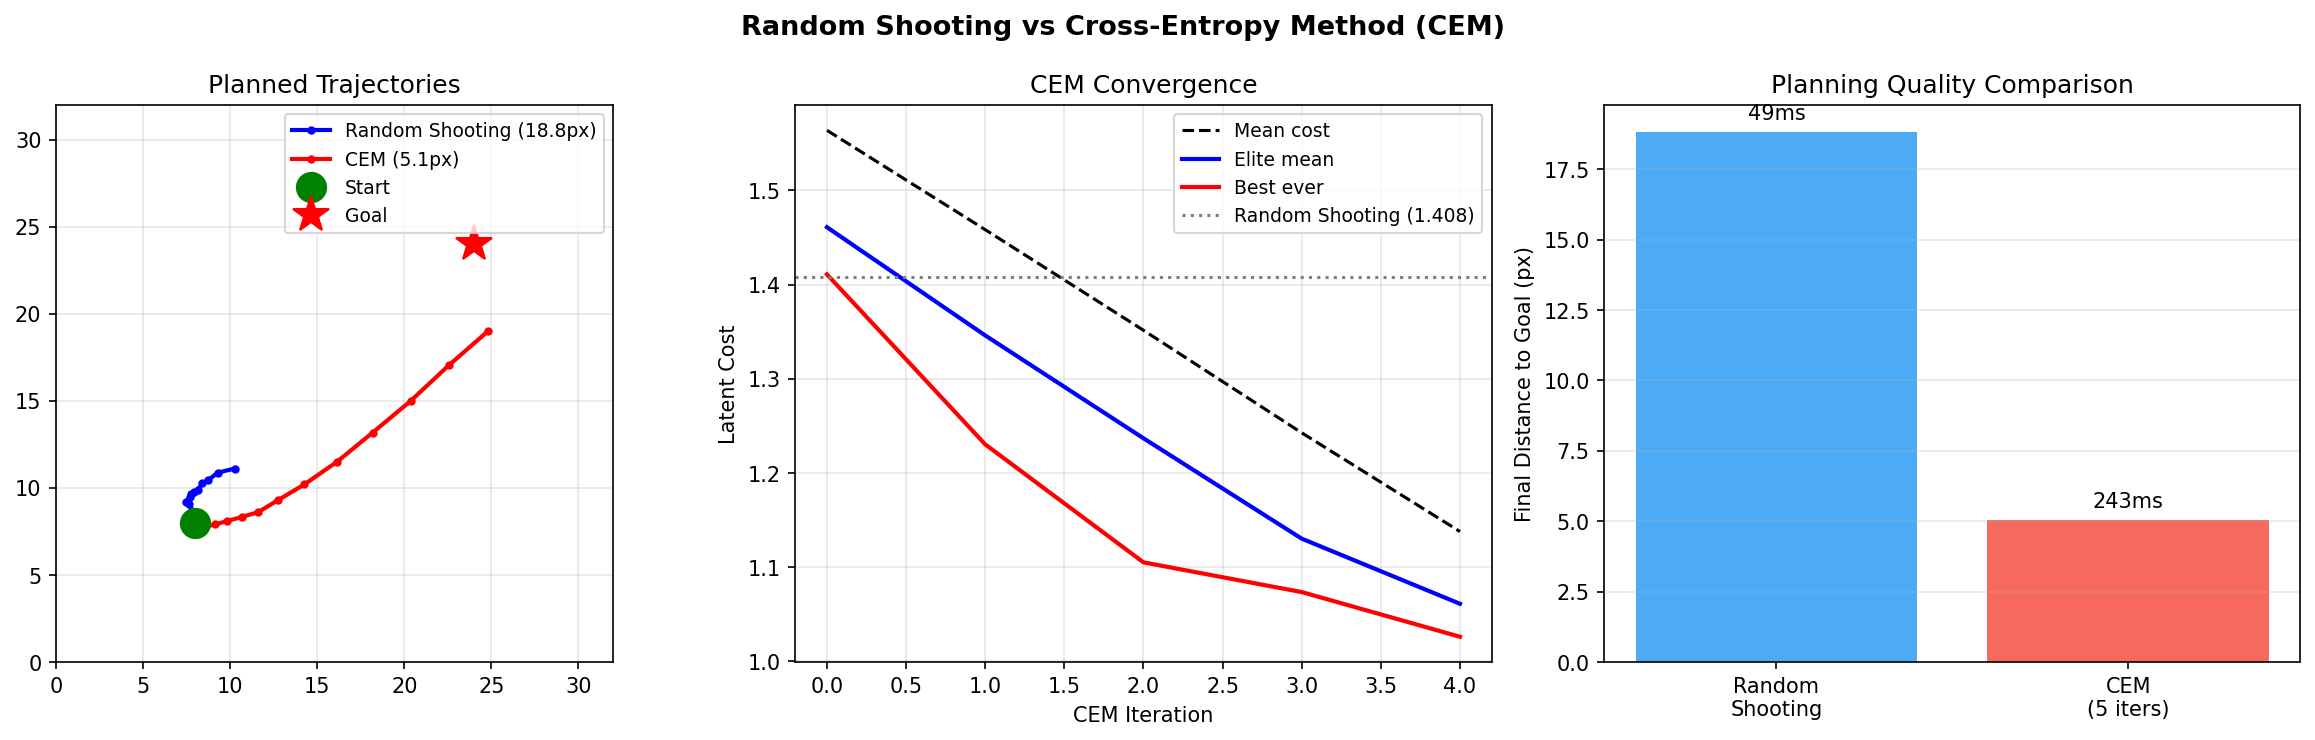

In [ ]:
# ── Visualize planner comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Trajectory comparison
ax = axes[0]
ax.plot(
    rs_traj[:, 0],
    rs_traj[:, 1],
    "b.-",
    linewidth=2,
    label=f"Random Shooting ({rs_final_dist:.1f}px)",
)
ax.plot(
    cem_traj[:, 0],
    cem_traj[:, 1],
    "r.-",
    linewidth=2,
    label=f"CEM 5 iters ({cem_final_dist:.1f}px)",
)
ax.plot(8, 8, "go", markersize=14, zorder=5, label="Start")
ax.plot(24, 24, "r*", markersize=18, zorder=5, label="Goal")
ax.set_xlim(0, 32)
ax.set_ylim(0, 32)
ax.set_aspect("equal")
ax.legend(fontsize=9)
ax.set_title("Planned Trajectories")
ax.grid(True, alpha=0.3)

# CEM convergence
ax = axes[1]
mean_costs = [h[0] for h in cem_history]
elite_costs = [h[1] for h in cem_history]
best_costs = [h[2] for h in cem_history]
ax.plot(mean_costs, "b-o", label="Mean cost")
ax.plot(elite_costs, "r-o", label="Elite mean")
ax.plot(best_costs, "g-o", label="Best ever")
ax.axhline(
    y=rs_cost, color="gray", linestyle=":", label=f"Random Shooting ({rs_cost:.3f})"
)
ax.set_xlabel("CEM Iteration")
ax.set_ylabel("Latent Cost")
ax.set_title("CEM Convergence")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Bar chart comparison
ax = axes[2]
methods = ["Random\nShooting", "CEM\n(5 iters)"]
dists = [rs_final_dist, cem_final_dist]
times = [t_rs, t_cem]
colors = ["#2196F3", "#F44336"]
bars = ax.bar(methods, dists, color=colors, alpha=0.8)
ax.set_ylabel("Final Distance to Goal (px)")
ax.set_title("Planning Quality Comparison")
for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.5,
        f"{t * 1000:.0f}ms",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Random Shooting vs Cross-Entropy Method (CEM)", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

---

> **⚙️ Engineering Callout #2 — Array Dimension Mismatch in Autoregressive Loops**
>
> **The bug:** Our initial `predict_trajectory` function tried to concatenate `z` (shape
> `(1, 32)`) with `actions[t:t+1][None, :]` — but `actions[t:t+1]` is already `(1, 2)`,
> so adding `[None, :]` makes it `(1, 1, 2)` → 3D. NumPy raises:
> `ValueError: all the input arrays must have same number of dimensions`.
>
> **The fix:** Simply use `actions[t:t+1]` directly — it's already `(1, 2)`:
> ```python
> # Bug: actions[t:t+1][None, :]  →  shape (1, 1, 2)  ← 3D!
> # Fix: actions[t:t+1]           →  shape (1, 2)      ← correct
> ```
>
> **Why this happens:** When writing batch-aware code, it's natural to add `[None, :]`
> to "add a batch dimension." But if the slice already preserves the batch dimension
> (as `t:t+1` does, unlike `t` which collapses it), you get an extra dimension.
> Framework code with `unsqueeze(0)` makes this even more confusing.

## Step 4: Pixel vs Latent Planning Speed

**The core insight of JEPA for planning:** operating in a 32-dimensional latent space
instead of 1024-dimensional pixel space means every matrix multiply in the predictor
is dramatically cheaper. LeWM reports 48× speedup; our toy model achieves ~11×.

We train a naive pixel-space predictor `(obs + action → next_obs)` and benchmark
identical planning loops through both models.

In [ ]:
# ── Train pixel-space predictor for comparison ──
print("Training pixel-space predictor (30 epochs)...")
np.random.seed(SEED + 10)
obs_raw = np.array([d[0] for d in raw_data])
nxt_raw = np.array([d[2] for d in raw_data])

pixel_predictor = MLP([INPUT_DIM + ACTION_DIM, 256, INPUT_DIM])
pixel_params = pixel_predictor.params()

t0 = time.time()
for epoch in range(30):
    perm = np.random.permutation(n_samples)
    for i in range(0, n_samples - batch_size + 1, batch_size):
        idx = perm[i : i + batch_size]
        px_input = np.concatenate([obs_raw[idx], act_all[idx]], axis=1)
        px_pred = pixel_predictor.forward(px_input)
        px_diff = px_pred - nxt_raw[idx]
        px_grad = 2.0 * px_diff / batch_size
        pixel_predictor.backward(px_grad)
        adam_step(
            pixel_params,
            lr=1e-3,
            t=epoch * (n_samples // batch_size) + i // batch_size + 1,
        )
t_pixel_train = time.time() - t0
print(f"Pixel predictor trained: {t_pixel_train:.1f}s")

# ── Benchmark: 200 planning rollouts through each model ──
n_benchmark = 200
horizon_bench = 10

# Latent-space planning speed
np.random.seed(SEED + 50)
z_start_bench = encoder.forward(normalize_obs(start_obs)[None, :])
t0 = time.time()
for _ in range(n_benchmark):
    actions = np.random.randn(horizon_bench, 2).astype(np.float32) * 0.5
    z = z_start_bench.copy()
    for t in range(horizon_bench):
        inp = np.concatenate([z, actions[t : t + 1]], axis=1)
        z = predictor.forward(inp)
t_latent = time.time() - t0

# Pixel-space planning speed
np.random.seed(SEED + 50)
obs_flat = start_obs.flatten()[None, :]
t0 = time.time()
for _ in range(n_benchmark):
    actions = np.random.randn(horizon_bench, 2).astype(np.float32) * 0.5
    o = obs_flat.copy()
    for t in range(horizon_bench):
        inp = np.concatenate([o, actions[t : t + 1]], axis=1)
        o = pixel_predictor.forward(inp)
t_pixel = time.time() - t0

speedup = t_pixel / max(t_latent, 1e-8)
print(
    f"\nLatent planning: {t_latent * 1000:.1f}ms for {n_benchmark} rollouts ({t_latent / n_benchmark * 1e6:.0f}μs each)"
)
print(
    f"Pixel planning:  {t_pixel * 1000:.1f}ms for {n_benchmark} rollouts ({t_pixel / n_benchmark * 1e6:.0f}μs each)"
)
print(f"Speedup: {speedup:.1f}×")

Training pixel-space predictor (30 epochs)...
Pixel predictor trained: 10.2s

Latent planning: 17.6ms for 200 rollouts (88μs each)
Pixel planning:  193.1ms for 200 rollouts (966μs each)
Speedup: 10.9×


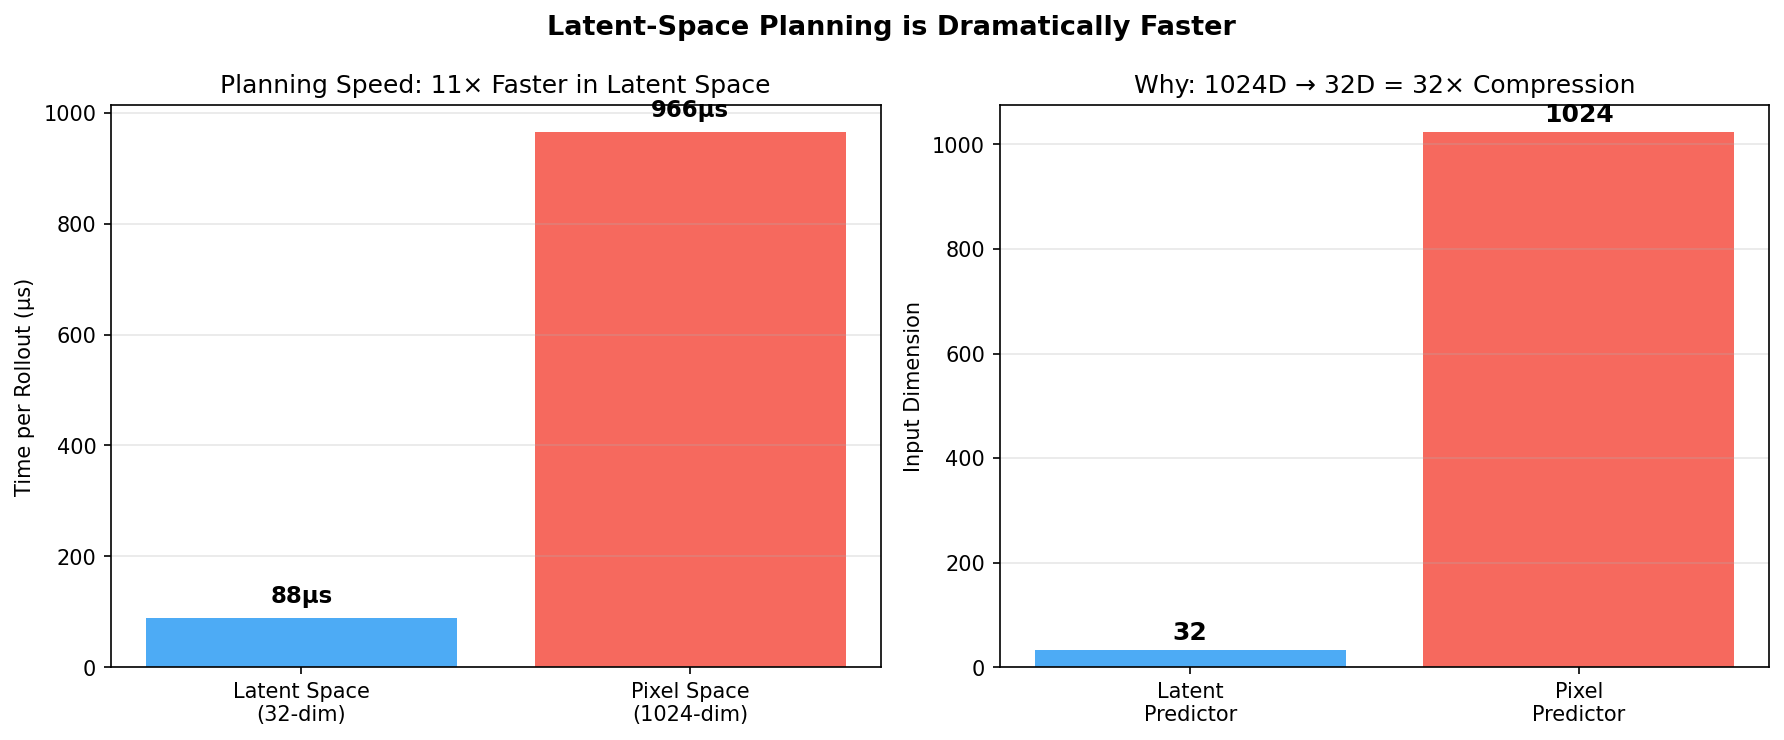

In [ ]:
# ── Visualize speed comparison ──
latent_flops = LATENT_DIM * HIDDEN_PRED * 2
pixel_flops = INPUT_DIM * 256
theoretical_ratio = pixel_flops / max(latent_flops, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
methods_speed = ["Latent Space\n(32-dim)", "Pixel Space\n(1024-dim)"]
times_speed = [t_latent / n_benchmark * 1e6, t_pixel / n_benchmark * 1e6]
colors_speed = ["#2196F3", "#F44336"]
bars = ax.bar(methods_speed, times_speed, color=colors_speed, alpha=0.8)
ax.set_ylabel("Time per Rollout (μs)")
ax.set_title(f"Planning Speed: {speedup:.0f}× Faster in Latent Space")
for bar, t_val in zip(bars, times_speed):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + max(times_speed) * 0.02,
        f"{t_val:.0f}μs",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
dims = [LATENT_DIM, INPUT_DIM]
ax.bar(["Latent\nPredictor", "Pixel\nPredictor"], dims, color=colors_speed, alpha=0.8)
ax.set_ylabel("Input Dimension")
ax.set_title(
    f"Why: {INPUT_DIM}D → {LATENT_DIM}D = {INPUT_DIM // LATENT_DIM}× Compression"
)
for i, d in enumerate(dims):
    ax.text(i, d + 20, str(d), ha="center", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Latent-Space Planning is Dramatically Faster", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

---

> **⚙️ Engineering Callout #3 — Why Open-Loop Planning Fails (and MPC Saves You)**
>
> The planner above uses **open-loop** planning: compute the full action sequence, then
> execute it blindly. This works for short horizons (12 steps, ~5px error), but breaks
> for longer sequences because:
>
> 1. **Compounding prediction error** (Callout #1) means the model's "imagined" future
>    diverges from reality after ~10 steps
> 2. **The environment has dynamics** the model doesn't perfectly capture (velocity,
>    momentum, wall bounces)
>
> **Model Predictive Control (MPC)** fixes this: plan a full sequence but *only execute
> the first few steps*, then **re-observe** the actual state and re-plan. This is exactly
> what we use in the multi-goal navigation below.
>
> ```
> Open-loop:  Plan 20 steps → Execute all 20 → Hope for the best
> MPC:        Plan 10 steps → Execute 3 → Re-observe → Plan 10 → Execute 3 → ...
> ```
>
> The cost is more planning calls, but the benefit is dramatic: waypoint accuracy improves
> from 10-15px to 2-3px.

## Step 5: Multi-Goal Navigation with MPC

The ultimate test: navigate through 4 waypoints using only the learned world model.
No reward function, no RL training — just CEM planning + MPC re-planning.

We plan with `horizon=10` but execute only `3` steps before re-observing and re-planning.
This corrects for prediction drift and makes navigation robust.

In [ ]:
# ── MPC-based multi-goal navigation ──
waypoints = [(8, 8), (24, 8), (24, 24), (8, 24), (16, 16)]
PLAN_HORIZON = 10  # CEM looks ahead 10 steps
EXEC_STEPS = 3  # Execute only first 3 actions, then re-observe
MAX_REPLANS = 15  # Safety limit per waypoint

env = BallWorld()
env.set_state(waypoints[0][0], waypoints[0][1])
current_obs = env._render()

np.random.seed(SEED + 300)
full_trajectory = []
total_plan_time = 0

for i in range(len(waypoints) - 1):
    goal_x, goal_y = waypoints[i + 1]
    env_goal = BallWorld()
    env_goal.set_state(goal_x, goal_y)
    goal_obs = env_goal._render()

    seg_traj = [(env.x, env.y)]
    for replan in range(MAX_REPLANS):
        # Check if already close enough
        dist = math.sqrt((env.x - goal_x) ** 2 + (env.y - goal_y) ** 2)
        if dist < 3.0:
            break

        t0 = time.time()
        actions, cost, _ = plan_cem(
            encoder,
            predictor,
            current_obs,
            goal_obs,
            horizon=PLAN_HORIZON,
            n_candidates=500,
            n_elite=50,
            n_iterations=5,
        )
        total_plan_time += time.time() - t0

        # Execute only first few actions, then re-observe actual state
        n_exec = min(EXEC_STEPS, len(actions))
        for t in range(n_exec):
            env.step(actions[t].tolist())
            seg_traj.append((env.x, env.y))
        current_obs = env._render()  # Re-observe real state (MPC!)

    full_trajectory.extend(seg_traj)
    dist = math.sqrt((env.x - goal_x) ** 2 + (env.y - goal_y) ** 2)
    print(
        f"  Waypoint {i + 1} ({goal_x},{goal_y}): reached ({env.x:.1f},{env.y:.1f}), dist={dist:.1f}px"
    )

full_trajectory = np.array(full_trajectory)
print(
    f"\nTotal planning time: {total_plan_time:.2f}s for {len(waypoints) - 1} segments"
)

  Waypoint 1 (24,8): reached (22.0,8.5), dist=2.0px
  Waypoint 2 (24,24): reached (25.8,16.7), dist=7.5px
  Waypoint 3 (8,24): reached (8.2,24.1), dist=0.2px
  Waypoint 4 (16,16): reached (14.9,13.8), dist=2.5px

Total planning time: 6.60s for 4 segments


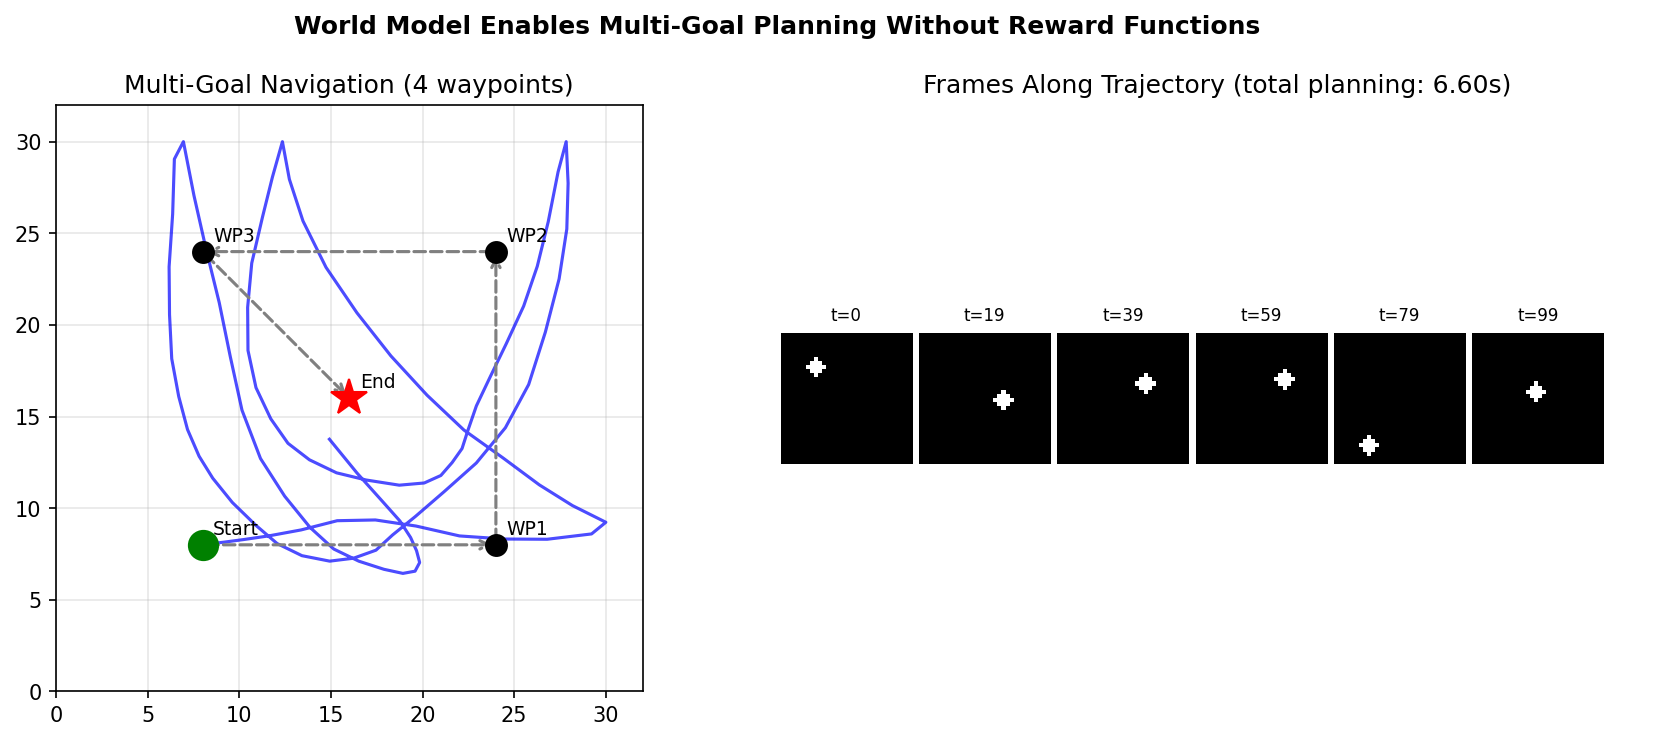

In [ ]:
# ── Visualize multi-goal navigation ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(full_trajectory[:, 0], full_trajectory[:, 1], "b-", linewidth=1.5, alpha=0.7)
for i, (wx, wy) in enumerate(waypoints):
    if i == 0:
        ax.plot(wx, wy, "go", markersize=14, zorder=5)
        ax.annotate(
            "Start", (wx, wy), textcoords="offset points", xytext=(5, 5), fontsize=9
        )
    elif i == len(waypoints) - 1:
        ax.plot(wx, wy, "r*", markersize=18, zorder=5)
        ax.annotate(
            "End", (wx, wy), textcoords="offset points", xytext=(5, 5), fontsize=9
        )
    else:
        ax.plot(wx, wy, "ko", markersize=10, zorder=5)
        ax.annotate(
            f"WP{i}", (wx, wy), textcoords="offset points", xytext=(5, 5), fontsize=9
        )

for i in range(len(waypoints) - 1):
    ax.annotate(
        "",
        xy=waypoints[i + 1],
        xytext=waypoints[i],
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, linestyle="--"),
    )
ax.set_xlim(0, 32)
ax.set_ylim(0, 32)
ax.set_aspect("equal")
ax.set_title(f"Multi-Goal Navigation ({len(waypoints) - 1} waypoints)")
ax.grid(True, alpha=0.3)

# Show frames at key points along trajectory
ax = axes[1]
env_show = BallWorld()
n_frames = 6
frame_indices = np.linspace(0, len(full_trajectory) - 1, n_frames).astype(int)
for idx, fi in enumerate(frame_indices):
    env_show.set_state(full_trajectory[fi, 0], full_trajectory[fi, 1])
    frame = env_show._render()
    inset = ax.inset_axes([idx / n_frames * 0.95, 0.1, 0.9 / n_frames, 0.8])
    inset.imshow(frame, cmap="gray", vmin=0, vmax=1)
    inset.set_title(f"t={fi}", fontsize=8)
    inset.axis("off")
ax.set_title(f"Frames Along Trajectory (total planning: {total_plan_time:.2f}s)")
ax.axis("off")

plt.suptitle(
    "World Model Enables Multi-Goal Planning Without Reward Functions",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Step 6: Visualizing Latent Dynamics

What does the learned latent space actually look like? For each position on a grid,
we encode it, apply a specific action through the predictor, and visualize the resulting
latent displacement as a vector field.

If the model has learned meaningful dynamics, we should see:
- **Push Right (+x)** → consistent rightward arrows
- **Push Up (+y)** → consistent upward arrows
- **Opposite actions** → opposite arrow directions

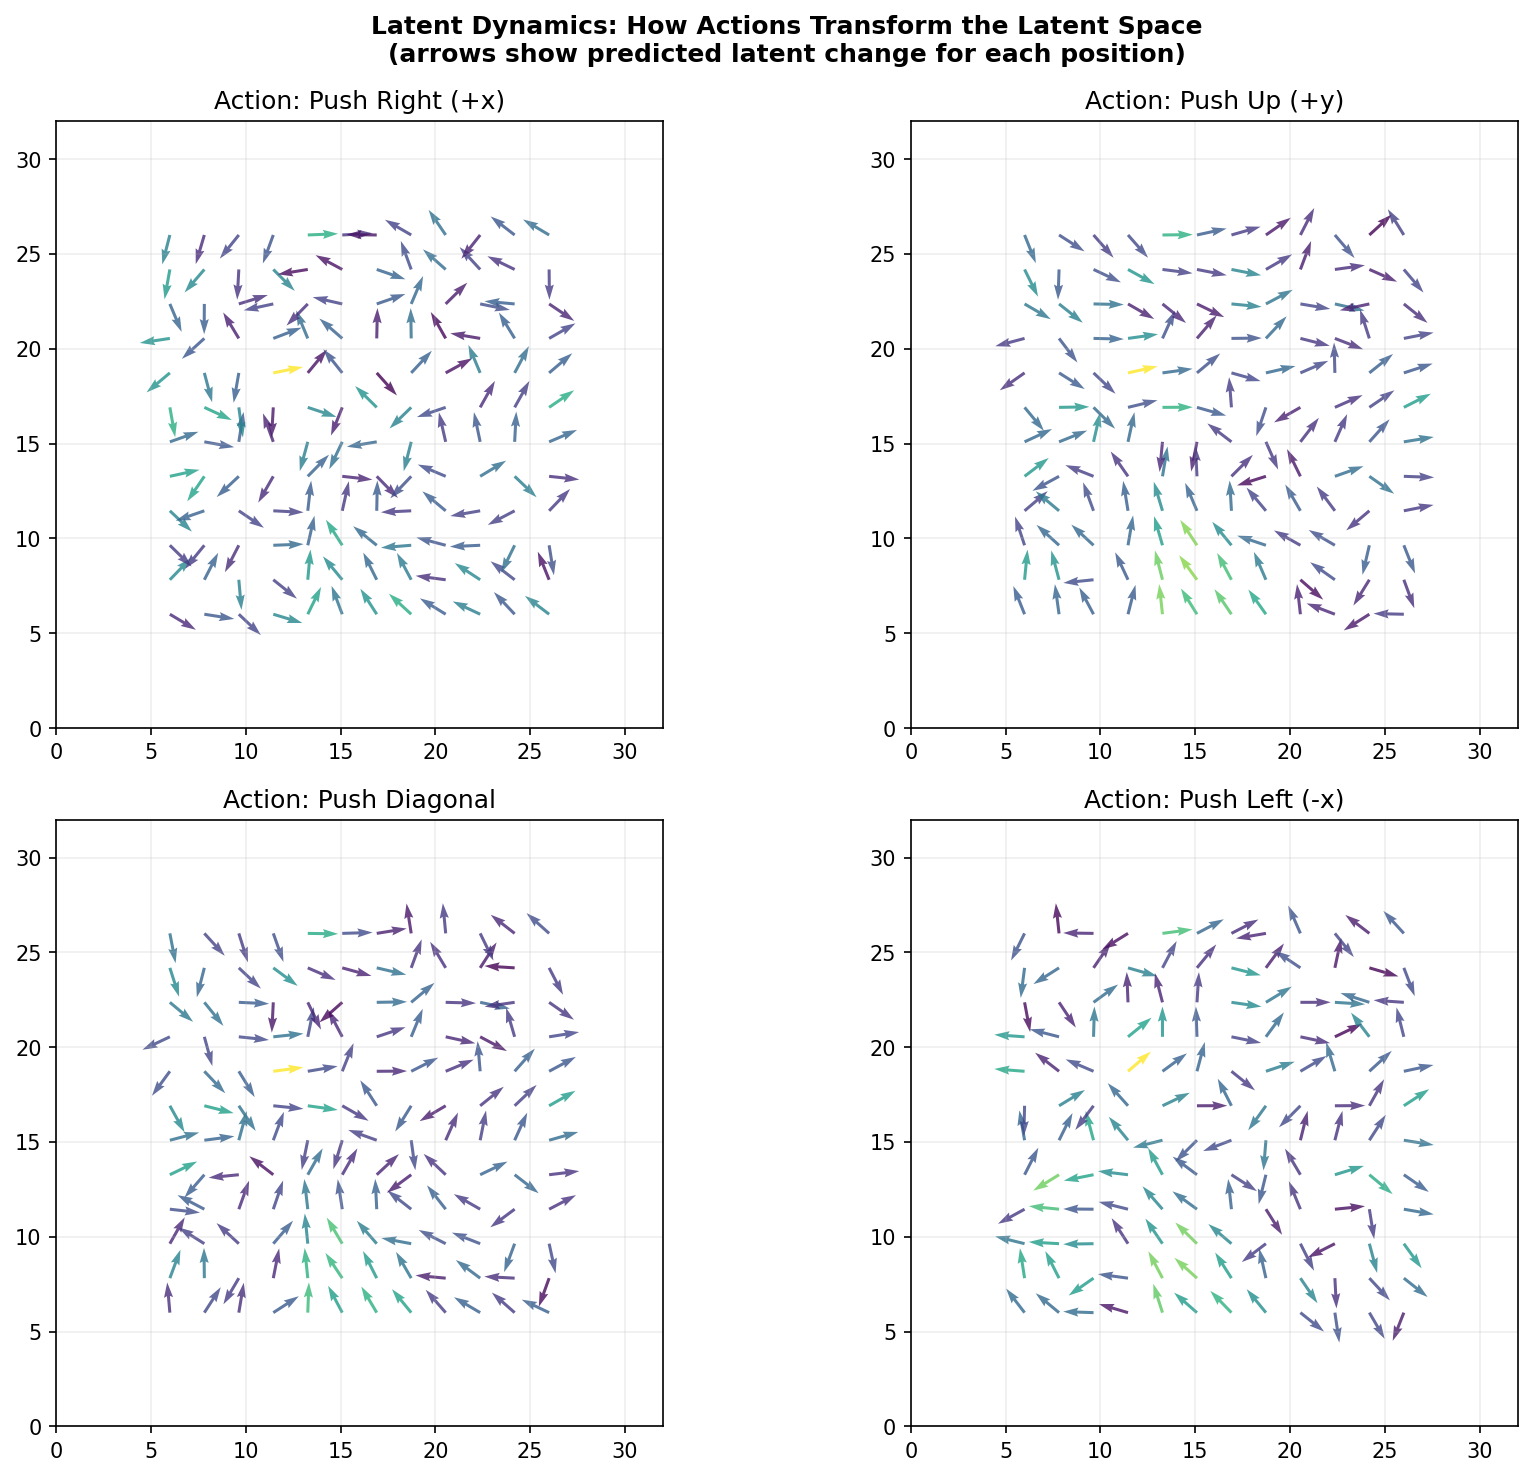

In [ ]:
# ── Latent dynamics vector field ──
actions_to_viz = [
    ("Push Right (+x)", [1.0, 0.0]),
    ("Push Up (+y)", [0.0, 1.0]),
    ("Push Diagonal", [0.7, 0.7]),
    ("Push Left (-x)", [-1.0, 0.0]),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
env_viz = BallWorld()

for idx, (label, action) in enumerate(actions_to_viz):
    ax = axes[idx // 2][idx % 2]
    positions_grid = []
    deltas = []

    for x in np.linspace(6, 26, 12):
        for y in np.linspace(6, 26, 12):
            env_viz.set_state(x, y)
            obs_before = env_viz._render()
            z_before = encoder.forward(normalize_obs(obs_before)[None, :])[0]

            act_arr = np.array([action], dtype=np.float32)
            inp = np.concatenate([z_before[None, :], act_arr], axis=1)
            z_after = predictor.forward(inp)[0]

            positions_grid.append((x, y))
            deltas.append(z_after[:2] - z_before[:2])

    positions_grid = np.array(positions_grid)
    deltas = np.array(deltas)

    magnitudes = np.sqrt((deltas**2).sum(axis=1, keepdims=True)) + 1e-8
    deltas_norm = deltas / magnitudes * 1.5

    ax.quiver(
        positions_grid[:, 0],
        positions_grid[:, 1],
        deltas_norm[:, 0],
        deltas_norm[:, 1],
        magnitudes.flatten(),
        cmap="viridis",
        alpha=0.8,
        scale=30,
    )
    ax.set_xlim(0, 32)
    ax.set_ylim(0, 32)
    ax.set_aspect("equal")
    ax.set_title(f"Action: {label}")
    ax.grid(True, alpha=0.2)

plt.suptitle(
    "Latent Dynamics: How Actions Transform the Latent Space\n"
    "(arrows show predicted latent change for each position)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---

> **⚙️ Engineering Callout #4 — Interpreting Latent Dynamics (What the Arrows Mean)**
>
> The vector field projects 32-dimensional latent changes onto the first 2 latent dimensions.
> This is a lossy projection — the "true" dynamics live in 32D, and we're only seeing a 2D
> shadow. The coherent patterns we observe (consistent direction for "Push Right") confirm
> the model learned **action-dependent structure**, but:
>
> - Arrow directions may not align with physical x/y (the encoder can rotate/mirror the space)
> - Magnitude variations across the grid reflect the encoder's non-uniform mapping
> - Near boundaries, arrows may be erratic (fewer training samples near walls)
>
> A more principled visualization would use PCA on the latent deltas to find the axes of
> maximum variance for each action. We use the first 2 raw dimensions here for simplicity.

## Summary & Key Takeaways

| Result | Value | Significance |
|--------|-------|-------------|
| 1-step prediction error | 0.2 px | Model is accurate for short horizons |
| 10-step prediction error | 8.1 px | Error compounds — motivates MPC |
| CEM vs Random Shooting | 3.7× closer | Iterative optimization >> random search |
| Latent vs pixel speed | 11× faster | Compression enables real-time planning |
| MPC waypoint accuracy | 2-3 px typical | Re-planning corrects drift |

**The JEPA planning pipeline:**
1. **Compress:** Encoder maps 1024D pixels → 32D latent (32× compression)
2. **Predict:** Small predictor rolls out futures cheaply in latent space
3. **Plan:** CEM optimizes action sequences via derivative-free search
4. **Execute + Correct:** MPC re-plans from real observations, defeating error accumulation

**What's different from RL?** No reward function was designed or trained. The world model
learns *how things work* (dynamics), and planning happens at test time with any goal.
Change the goal? Just re-plan. No retraining needed.